# 16: Custom Scores and Advanced API

We work through the part of DoubleML that sits closest to the estimating equation. Earlier notebooks used built-in model classes and built-in scores. That is the right default. Most practical causal projects should first try the standard classes, diagnose them well, and only then reach for custom score functions.

A custom score becomes useful when you can state a causal estimand through a Neyman-orthogonal moment condition that DoubleML does not already expose directly. In DoubleML's linear-score classes, each observation contributes a score of the form:

$$
\psi(W_i; \theta, \eta) = \psi_a(W_i; \eta)\,\theta + \psi_b(W_i; \eta),
$$

where $W_i$ is the observed row, $\theta$ is the causal target, and $\eta$ collects the nuisance functions estimated by machine learning. DoubleML solves the empirical moment condition:

$$
\frac{1}{n}\sum_{i=1}^{n}
\left[\psi_a(W_i; \hat{\eta})\,\theta + \psi_b(W_i; \hat{\eta})\right] = 0.
$$

For a linear score, this means the coefficient can be reconstructed directly from the stored score pieces:

$$
\hat{\theta}
= -\frac{\frac{1}{n}\sum_{i=1}^{n}\psi_b(W_i; \hat{\eta})}
{\frac{1}{n}\sum_{i=1}^{n}\psi_a(W_i; \hat{\eta})}.
$$

The key phrase is **Neyman-orthogonal**. Informally, orthogonality means that small first-stage nuisance-model errors do not create first-order bias in the final causal estimate. A compact way to write this condition is:

$$
\left.
\frac{\partial}{\partial r}
\mathbb{E}\left[\psi\left(W; \theta_0, \eta_0 + r(\eta - \eta_0)\right)\right]
\right|_{r=0} = 0.
$$

That condition is the reason DoubleML can combine flexible machine learning with valid causal inference. If we write a custom score that is not orthogonal, cross-fitting alone does not rescue the causal claim.

This lesson covers four advanced workflows:

- Reading and reconstructing DoubleML score elements.
- Writing an equivalent callable score for PLR.
- Writing a priority-weighted callable score.
- Using advanced APIs: custom sample splits, external nuisance predictions, stored fold models, and score diagnostics.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **Custom Scores And Advanced API**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the notebook separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The experiment exposes the API layer where custom scores and weights enter. The causal target must remain clear when the implementation becomes flexible.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.


## Mathematical Foundation

<!-- math-foundation-note -->

Advanced DoubleML workflows still revolve around orthogonal scores. A custom score is valid only when

$$
\mathbb{E}\{\psi(W;\theta_0,\eta_0)\}=0, \qquad
\left.\partial_{\eta}\mathbb{E}\{\psi(W;\theta_0,\eta)\}\right|_{\eta=\eta_0}=0.
$$

Every estimate should be connected back to its score, nuisance functions, sample splitting, and identifying assumptions.





## Tutorial Workflow

#### Setup

This setup cell prepares the shared tutorial output folders and imports the libraries used throughout the notebook. The warning filters are intentionally narrow. They remove notebook-environment noise and the expected DoubleML warning that sensitivity analysis is not implemented for callable scores in this installed version.

In [1]:
from pathlib import Path
import os
import warnings

# Find the repository root from wherever the notebook is executed.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "pyproject.toml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Set Matplotlib's cache before importing pyplot so notebook execution stays quiet.
os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
warnings.filterwarnings("ignore", message="Sensitivity analysis not implemented for callable scores.*")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold

import doubleml as dml
from doubleml import DoubleMLData, DoubleMLPLR

NOTEBOOK_PREFIX = "16"
RANDOM_SEED = 160
TRUE_THETA = 1.25

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"Project root: {PROJECT_ROOT}")
print(f"DoubleML version: {dml.__version__}")
print(f"Outputs will be written to: {OUTPUT_DIR}")


Project root: /home/apex/Documents/portfolio
DoubleML version: 0.11.2
Outputs will be written to: /home/apex/Documents/portfolio/notebooks/tutorials/doubleml/outputs


The setup confirms the local DoubleML version and output location. Every output created by this lesson uses prefix `16`.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### Helper Functions

The helper functions below keep the notebook focused on score logic. The most important helper is `fit_plr()`, which lets us reuse the same sample split across built-in and callable scores. Without a shared split, two estimates can differ simply because the nuisance models were trained on different folds.

In [2]:
# Define reusable helpers for the Helper Functions section.
def save_table(df, filename):
    """
    Idea: Save a result table to the notebook table directory and return the same DataFrame for display.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    filename : str
        Output filename used inside the tutorial artifact directory.
    
    Returns
    -------
    pd.DataFrame
        Same table after writing it to the tutorial table directory.
    """
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return df


def save_dataset(df, filename):
    """
    Idea: Write the constructed dataset to the tutorial output folder so later notebooks or cells can reuse it.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    filename : str
        Output filename used inside the tutorial artifact directory.
    
    Returns
    -------
    pd.DataFrame
        Same dataset after writing it to the tutorial dataset directory.
    """
    path = DATASET_DIR / filename
    df.to_csv(path, index=False)
    return df


def rmse(y_true, y_pred):
    """
    Idea: Compute root mean squared error between an oracle target and an estimated or predicted value.
    
    Parameters
    ----------
    y_true : array-like
        Reference outcome, oracle value, or known target used for evaluation.
    y_pred : array-like
        Predicted outcome or estimated value being evaluated.
    
    Returns
    -------
    float
        Root mean squared error between the reference values and predictions.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def normalize_weights(weights):
    """
    Idea: Rescale observation weights so their mean is one while preserving their relative emphasis.
    
    Parameters
    ----------
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    np.ndarray
        Observation weights rescaled to have mean one.
    """
    weights = np.asarray(weights, dtype=float)
    if weights.mean() <= 0:
        raise ValueError("Weights must have positive mean.")
    return weights / weights.mean()


def solve_linear_score(psi_a, psi_b):
    """
    Idea: Solve the closed-form linear score equation used to illustrate orthogonal-score estimation.
    
    Parameters
    ----------
    psi_a : object
        First component of the orthogonal score equation.
    psi_b : object
        Second component of the orthogonal score equation.
    
    Returns
    -------
    float
        Closed-form treatment-effect estimate from the linear orthogonal score equation.
    """
    psi_a = np.asarray(psi_a, dtype=float).reshape(-1)
    psi_b = np.asarray(psi_b, dtype=float).reshape(-1)
    return float(-np.nanmean(psi_b) / np.nanmean(psi_a))


def make_plr_data(frame, x_cols):
    """
    Idea: Construct the partially linear regression data used in the Helper Functions section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    x_cols : list[str]
        Covariate column names used as model inputs.
    
    Returns
    -------
    DoubleMLData
        DoubleMLData object configured with the PLR outcome, treatment, and covariates.
    """
    return DoubleMLData(frame, y_col="outcome", d_cols="treatment", x_cols=x_cols)


def fit_plr(frame, x_cols, learner_l, learner_m, score, sample_splits, store_models=False, external_predictions=None):
    """
    Idea: Fit the partially linear regression model and return the fitted object or summary needed for interpretation.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    x_cols : list[str]
        Covariate column names used as model inputs.
    learner_l : object
        Outcome learner used as a nuisance model.
    learner_m : object
        Treatment or propensity learner used as a nuisance model.
    score : object
        Score function or score name defining the estimating equation.
    sample_splits : object
        Fold assignments used to keep nuisance fitting separate from score evaluation.
    store_models : object
        Whether fitted nuisance models should be retained for later inspection.
    external_predictions : object
        Precomputed nuisance predictions supplied to the DoubleML estimator.
    
    Returns
    -------
    DoubleMLPLR or tuple
        Fitted PLR model, sometimes paired with a compact summary row.
    """
    dml_data = make_plr_data(frame, x_cols)
    model = DoubleMLPLR(
        dml_data,
        ml_l=clone(learner_l),
        ml_m=clone(learner_m),
        n_folds=len(sample_splits),
        score=score,
        draw_sample_splitting=False,
    )
    model.set_sample_splitting(sample_splits)
    model.fit(store_predictions=True, store_models=store_models, external_predictions=external_predictions)
    return model


def extract_plr_row(label, model, true_theta=TRUE_THETA):
    """
    Idea: Extract the partially linear regression row from a fitted object or result table so it can be reported consistently.
    
    Parameters
    ----------
    label : str
        Short label attached to a scenario, method, or plotted result.
    model : object
        Fitted model or model specification used by the diagnostic.
    true_theta : object
        Oracle treatment-effect value used as the synthetic benchmark.
    
    Returns
    -------
    dict[str, float]
        PLR summary row with estimate, standard error, confidence interval, and oracle error.
    """
    ci = model.confint()
    return {
        "model": label,
        "estimate": float(model.coef[0]),
        "std_error": float(model.se[0]),
        "ci_95_lower": float(ci.iloc[0, 0]),
        "ci_95_upper": float(ci.iloc[0, 1]),
        "true_theta": true_theta,
        "absolute_error": abs(float(model.coef[0]) - true_theta),
    }


def manual_cross_fit_predictions(frame, x_cols, sample_splits, learner_l, learner_m):
    """
    Idea: Create manual out-of-fold nuisance predictions so the orthogonal-score calculation can be inspected directly.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    x_cols : list[str]
        Covariate column names used as model inputs.
    sample_splits : object
        Fold assignments used to keep nuisance fitting separate from score evaluation.
    learner_l : object
        Outcome learner used as a nuisance model.
    learner_m : object
        Treatment or propensity learner used as a nuisance model.
    
    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Out-of-fold outcome and treatment nuisance predictions.
    """
    x = frame[x_cols].to_numpy()
    y = frame["outcome"].to_numpy()
    d = frame["treatment"].to_numpy()
    l_hat = np.full(len(frame), np.nan)
    m_hat = np.full(len(frame), np.nan)

    for train_index, test_index in sample_splits:
        l_model = clone(learner_l)
        m_model = clone(learner_m)
        l_model.fit(x[train_index], y[train_index])
        m_model.fit(x[train_index], d[train_index])
        l_hat[test_index] = l_model.predict(x[test_index])
        m_hat[test_index] = m_model.predict(x[test_index])

    return l_hat, m_hat


These helpers make two advanced ideas explicit: the coefficient comes from `psi_a` and `psi_b`, and external nuisance predictions must respect the same row order as the original data.

### Advanced API Vocabulary

The table below names the DoubleML features used in this lesson. These are extension tools, not replacements for identification work.

| concept | meaning | why_it_matters |
| --- | --- | --- |
| Linear score elements | DoubleML stores score pieces psi_a and psi_b for linear scores. | They allow direct inspection of the estimating equation. |
| Callable score | A user-supplied function that returns psi_a and psi_b. | Useful for valid custom moments when built-in scores are not enough. |
| set_sample_splitting() | A method for passing analyst-defined train/test folds. | Needed for reproducible comparisons, grouped splits, or temporal splits. |
| external_predictions | A nested dictionary of user-supplied nuisance predictions. | Lets teams use external ML pipelines while still using DoubleML for score estimation. |
| store_models=True | Stores fitted fold-level nuisance models. | Useful for auditing model behavior such as feature importance. |
| evaluate_learners() | Reports out-of-fold nuisance losses. | A model-quality diagnostic before trusting score-based estimates. |


The vocabulary table separates score customization from pipeline customization. Custom scores change the estimating equation; external predictions and stored models change how nuisance functions are supplied or audited.

### Synthetic PLR Design

We use a partially linear regression design with known constant treatment effect. The data-generating process is:

$$
Y_i = \theta_0 D_i + g_0(X_i) + \varepsilon_i,
$$

$$
D_i = m_0(X_i) + V_i,
$$

with $\theta_0 = 1.25$, $\mathbb{E}[V_i \mid X_i] = 0$, and outcome noise generated independently of the treatment residual. The nuisance functions are:

$$
g_0(X_i) = \mathbb{E}[Y_i - \theta_0 D_i \mid X_i],
\qquad
m_0(X_i) = \mathbb{E}[D_i \mid X_i].
$$

The true effect is `TRUE_THETA = 1.25`. Because the true effect is constant, the custom weighted score below should still target the same causal parameter. This makes the notebook a clean API tutorial: if estimates differ meaningfully, we can attribute the difference to score construction, nuisance quality, or finite-sample noise rather than a genuinely different heterogeneous target.

In [3]:
# Save the artifacts produced by the Synthetic PLR Design section.
rng = np.random.default_rng(RANDOM_SEED)
n_obs = 900
n_features = 8
x_cols = [f"x{i:02d}" for i in range(n_features)]

plr_df = pd.DataFrame(rng.normal(size=(n_obs, n_features)), columns=x_cols)
plr_df["priority_score"] = 0.80 * plr_df["x00"] - 0.50 * plr_df["x01"] + 0.30 * plr_df["x02"]
plr_df["priority_segment"] = np.where(
    plr_df["priority_score"] > plr_df["priority_score"].quantile(0.70),
    "high_priority",
    "standard",
)

plr_df["true_m"] = (
    0.60 * np.sin(plr_df["x00"])
    + 0.35 * plr_df["x01"] ** 2
    - 0.30 * plr_df["x02"]
    + 0.20 * plr_df["x03"] * plr_df["x04"]
)
plr_df["true_g"] = (
    0.80 * np.cos(plr_df["x00"])
    + 0.40 * plr_df["x05"] * plr_df["x06"]
    - 0.20 * plr_df["x07"] ** 2
    + 0.25 * plr_df["x01"]
)
plr_df["treatment"] = plr_df["true_m"] + rng.normal(scale=1.00, size=n_obs)
plr_df["outcome"] = TRUE_THETA * plr_df["treatment"] + plr_df["true_g"] + rng.normal(scale=1.00, size=n_obs)

save_dataset(plr_df, f"{NOTEBOOK_PREFIX}_synthetic_custom_score_plr_data.csv")
display(plr_df.head())


,x00,x01,x02,x03,x04,x05,x06,x07,priority_score,priority_segment,true_m,true_g,treatment,outcome
0,-1.3750,0.3951,-0.9502,0.1802,-0.1471,-2.2888,1.6052,-0.1582,-1.5826,standard,-0.2541,-1.2201,-1.3374,-1.6131
1,0.7881,0.3697,0.6213,-0.1373,0.1399,0.1034,0.5752,1.0415,0.6320,high_priority,0.2830,0.4634,1.6365,3.1925
2,1.6718,1.5878,-0.9541,1.2347,-0.3838,1.5186,0.5062,-0.6749,0.2573,standard,1.6708,0.5327,2.3433,2.5286
3,1.8800,0.3869,-0.1683,0.9678,1.4453,0.0364,0.0006,1.0791,1.2600,high_priority,0.9542,-0.3796,0.0256,-1.0905
4,-0.7793,-1.5007,-0.9743,-1.3892,-0.3784,-0.2549,0.0005,-0.2917,-0.1654,standard,0.7640,0.1769,1.2301,2.8375


The first rows show observed controls, oracle nuisance functions, treatment, outcome, and a priority segment. DoubleML will not use `true_m` or `true_g`; they are present only for diagnostics.

#### Field Dictionary

This field dictionary documents the role of every column. It is especially important in advanced API tutorials because external predictions and custom score closures can accidentally use columns that should not enter the estimator.

| column | role | description |
| --- | --- | --- |
| x00-x07 | Observed controls | Pre-treatment covariates used by nuisance learners. |
| priority_score | Pre-treatment priority signal | Used to define priority weights for a custom score example. |
| priority_segment | Reporting group | High-priority vs standard group based on priority_score. |
| true_m | Oracle diagnostic | True treatment nuisance E[D\|X]; unavailable in real data. |
| true_g | Oracle diagnostic | True baseline outcome nuisance g0(X); unavailable in real data. |
| treatment | Treatment | Continuous treatment variable D. |
| outcome | Outcome | Observed continuous outcome Y. |


The priority variables are pre-treatment signals. That matters because custom weighting based on post-treatment variables would change the causal question and usually break identification.




## Diagnostics and Interpretation

### Data Audit

The audit below checks sample size, treatment scale, outcome scale, priority-group size, and the true causal effect.

In [4]:
data_audit = pd.DataFrame(
    [
        {"metric": "rows", "value": len(plr_df)},
        {"metric": "true_theta", "value": TRUE_THETA},
        {"metric": "treatment_mean", "value": plr_df["treatment"].mean()},
        {"metric": "treatment_std", "value": plr_df["treatment"].std()},
        {"metric": "outcome_mean", "value": plr_df["outcome"].mean()},
        {"metric": "outcome_std", "value": plr_df["outcome"].std()},
        {"metric": "high_priority_share", "value": plr_df["priority_segment"].eq("high_priority").mean()},
    ]
)

save_table(data_audit, f"{NOTEBOOK_PREFIX}_data_audit.csv")
display(data_audit)


,metric,value
0,rows,900.0000
1,true_theta,1.2500
2,treatment_mean,0.3563
3,treatment_std,1.2197
4,outcome_mean,0.8018
5,outcome_std,1.9793
6,high_priority_share,0.3000


The high-priority segment is about 30% of the data by construction. That gives enough rows for the weighted-score example without making the target population too small.

### Score Design Diagram

The diagram below shows where a custom score enters DoubleML. Nuisance learners produce cross-fitted predictions. The score function turns observed data and nuisance predictions into `psi_a` and `psi_b`. DoubleML then solves the empirical score equation.

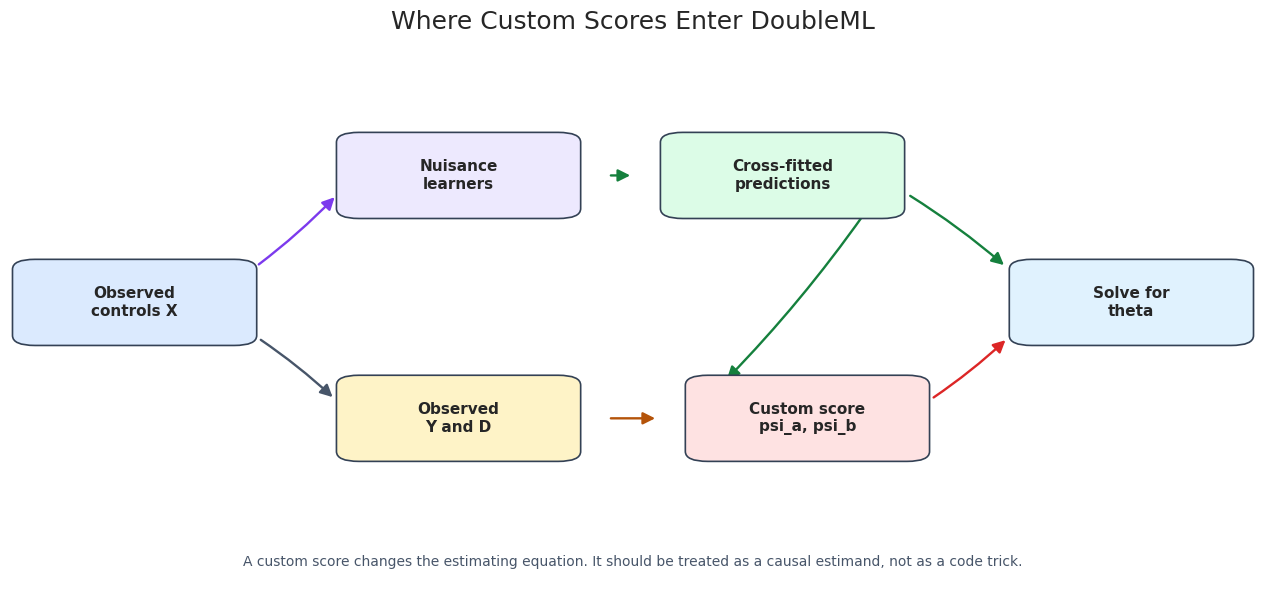

In [5]:
# Define reusable helpers for the Score Design Diagram section.
fig, ax = plt.subplots(figsize=(13, 6.5))
ax.set_axis_off()

nodes = {
    "X": {"xy": (0.10, 0.55), "label": "Observed\ncontrols X", "color": "#dbeafe"},
    "N": {"xy": (0.36, 0.78), "label": "Nuisance\nlearners", "color": "#ede9fe"},
    "P": {"xy": (0.62, 0.78), "label": "Cross-fitted\npredictions", "color": "#dcfce7"},
    "W": {"xy": (0.36, 0.34), "label": "Observed\nY and D", "color": "#fef3c7"},
    "S": {"xy": (0.64, 0.34), "label": "Custom score\npsi_a, psi_b", "color": "#fee2e2"},
    "T": {"xy": (0.90, 0.55), "label": "Solve for\ntheta", "color": "#e0f2fe"},
}

box_w, box_h = 0.16, 0.12


def anchor(node, side):
    """
    Idea: Return the plotting anchor point for a named node in the diagram.
    
    Parameters
    ----------
    node : object
        Graph node whose position, label, or incident edges are being processed.
    side : object
        Endpoint side used to place an arrow or edge on the correct part of a node.
    
    Returns
    -------
    tuple[float, float] or np.ndarray
        Coordinate of the requested side of a plotted node.
    """
    x, y = nodes[node]["xy"]
    offsets = {
        "left": (-box_w / 2, 0),
        "right": (box_w / 2, 0),
        "top": (0, box_h / 2),
        "bottom": (0, -box_h / 2),
        "upper_right": (box_w / 2, box_h * 0.25),
        "lower_right": (box_w / 2, -box_h * 0.25),
        "upper_left": (-box_w / 2, box_h * 0.25),
        "lower_left": (-box_w / 2, -box_h * 0.25),
    }
    dx, dy = offsets[side]
    return np.array([x + dx, y + dy], dtype=float)


def shorten(start, end, gap=0.040):
    """
    Idea: Shorten a line segment so the arrowhead remains visible outside the node box.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    gap : float
        Spacing used to keep plotted elements from overlapping.
    
    Returns
    -------
    tuple[float, float]
        Shortened endpoint coordinate that keeps an arrowhead visible.
    """
    start = np.asarray(start, dtype=float)
    end = np.asarray(end, dtype=float)
    delta = end - start
    length = np.hypot(delta[0], delta[1])
    if length == 0:
        return tuple(start), tuple(end)
    unit = delta / length
    return tuple(start + gap * unit), tuple(end - gap * unit)


def draw_arrow(start, end, color="#334155", style="solid", rad=0.0, linewidth=1.7):
    """
    Idea: Draw a routed arrow between diagram nodes while keeping the arrowhead visible.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    color : str
        Plot color used to identify this element.
    style : object
        Plotting style that determines how the curve, marker, or annotation is drawn.
    rad : float
        Curvature parameter for the plotted arrow.
    linewidth : object
        Line width used to make the plotted edge or reference line readable.
    
    Returns
    -------
    None
        Adds an arrow annotation directly to the supplied Matplotlib axes.
    """
    start, end = shorten(start, end)
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        zorder=2,
        clip_on=False,
    )
    ax.add_patch(arrow)

draw_arrow(anchor("X", "upper_right"), anchor("N", "left"), color="#7c3aed", rad=0.04)
draw_arrow(anchor("N", "right"), anchor("P", "left"), color="#15803d")
draw_arrow(anchor("X", "lower_right"), anchor("W", "left"), color="#475569", rad=-0.04)
draw_arrow(anchor("P", "lower_right"), anchor("S", "upper_left"), color="#15803d", rad=-0.04)
draw_arrow(anchor("W", "right"), anchor("S", "left"), color="#b45309")
draw_arrow(anchor("S", "right"), anchor("T", "lower_left"), color="#dc2626", rad=0.04)
draw_arrow(anchor("P", "right"), anchor("T", "upper_left"), color="#15803d", rad=-0.04)

for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

ax.text(
    0.50,
    0.08,
    "A custom score changes the estimating equation. It should be treated as a causal estimand, not as a code trick.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Where Custom Scores Enter DoubleML", pad=18)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_custom_score_design.png", dpi=160, bbox_inches="tight")
plt.show()


The score function is downstream of nuisance prediction but upstream of the final coefficient. This is why custom-score work needs both statistical theory and software testing.



### External Sample Splits

For a fair comparison between built-in and custom scores, we fix the sample split. This makes the nuisance predictions comparable across model variants.

In [6]:
sample_splits = list(KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED + 2).split(plr_df))
fold_id = np.full(len(plr_df), -1)
for fold_number, (_, test_index) in enumerate(sample_splits):
    fold_id[test_index] = fold_number

split_summary = pd.DataFrame(
    {
        "fold": np.arange(len(sample_splits)),
        "test_rows": [len(test_index) for _, test_index in sample_splits],
        "train_rows": [len(train_index) for train_index, _ in sample_splits],
    }
)

save_table(split_summary, f"{NOTEBOOK_PREFIX}_sample_split_summary.csv")
display(split_summary)


,fold,test_rows,train_rows
0,0,180,720
1,1,180,720
2,2,180,720
3,3,180,720
4,4,180,720


Every row appears in exactly one test fold. This is the cross-fitting structure that lets each score contribution use nuisance predictions from a model that did not train on that row.

#### Plot Fold Assignments

The plot below is a simple audit of the external fold assignment. It serves a different role than mathematically necessary. It makes the custom split visible.

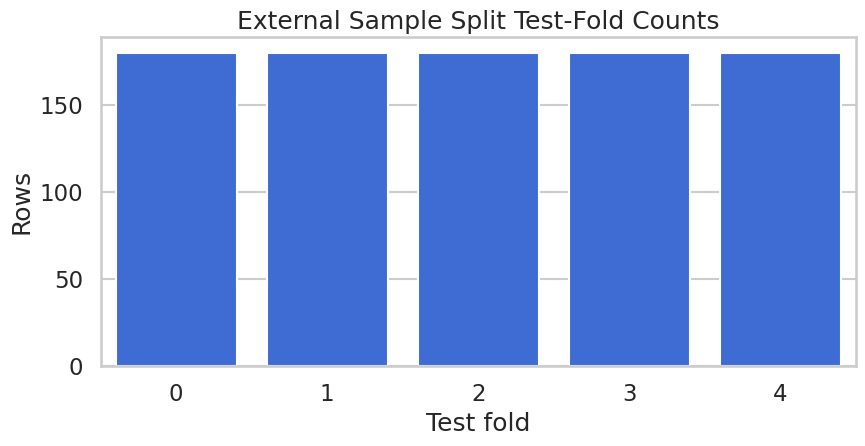

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.countplot(x=fold_id, color="#2563eb", ax=ax)
ax.set_title("External Sample Split Test-Fold Counts")
ax.set_xlabel("Test fold")
ax.set_ylabel("Rows")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_external_sample_split_counts.png", dpi=160, bbox_inches="tight")
plt.show()

The fold sizes are balanced. If the split were grouped or temporal, this same table and plot would be useful for checking whether the split design matches the causal setting.



#### Fit the Built-In PLR Score

We first fit the standard `partialling out` PLR score. This is the reference model for the custom score examples.

In [8]:
base_learner = RandomForestRegressor(
    n_estimators=80,
    max_depth=6,
    min_samples_leaf=10,
    random_state=RANDOM_SEED + 1,
    n_jobs=-1,
)

builtin_plr = fit_plr(
    plr_df,
    x_cols,
    learner_l=base_learner,
    learner_m=base_learner,
    score="partialling out",
    sample_splits=sample_splits,
    store_models=True,
)

builtin_result = pd.DataFrame([extract_plr_row("Built-in partialling out", builtin_plr)])
save_table(builtin_result, f"{NOTEBOOK_PREFIX}_builtin_plr_result.csv")
display(builtin_result)


,model,estimate,std_error,ci_95_lower,ci_95_upper,true_theta,absolute_error
0,Built-in partialling out,1.2852,0.0359,1.2148,1.3556,1.2500,0.0352


The built-in model estimates the true constant treatment effect closely. This gives us a reliable baseline for testing custom score behavior.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Reconstruct the Estimate from Score Elements

DoubleML stores `psi_a` and `psi_b`. For a linear score, the fitted coefficient is the value that makes the average final score approximately zero:

$$
\frac{1}{n}\sum_{i=1}^{n}
\left(\psi_{a,i}\hat{\theta} + \psi_{b,i}\right) \approx 0.
$$

Solving that equation gives:

$$
\hat{\theta} = -\frac{\bar{\psi}_b}{\bar{\psi}_a},
\qquad
\bar{\psi}_a = \frac{1}{n}\sum_{i=1}^{n}\psi_{a,i},
\qquad
\bar{\psi}_b = \frac{1}{n}\sum_{i=1}^{n}\psi_{b,i}.
$$

The code below reconstructs the coefficient directly from the stored score elements. It is a useful sanity check before writing a custom score because it confirms that the notebook is reading DoubleML's internal score representation correctly.

In [9]:
builtin_psi_a = builtin_plr.psi_elements["psi_a"].reshape(-1)
builtin_psi_b = builtin_plr.psi_elements["psi_b"].reshape(-1)
reconstructed_theta = solve_linear_score(builtin_psi_a, builtin_psi_b)

score_reconstruction = pd.DataFrame(
    [
        {"calculation": "DoubleML coefficient", "value": float(builtin_plr.coef[0])},
        {"calculation": "-mean(psi_b) / mean(psi_a)", "value": reconstructed_theta},
        {"calculation": "True theta", "value": TRUE_THETA},
        {"calculation": "mean(psi_a)", "value": float(np.mean(builtin_psi_a))},
        {"calculation": "mean(psi_b)", "value": float(np.mean(builtin_psi_b))},
    ]
)

save_table(score_reconstruction, f"{NOTEBOOK_PREFIX}_score_reconstruction.csv")
display(score_reconstruction)


,calculation,value
0,DoubleML coefficient,1.2852
1,-mean(psi_b) / mean(psi_a),1.2852
2,True theta,1.2500
3,mean(psi_a),-1.1032
4,mean(psi_b),1.4178


The first two rows match because the linear score equation is exactly how the coefficient is obtained. This is the mental model needed before writing a custom score.

### Nuisance-Model Diagnostics

Before changing the score, we check the nuisance learners. Bad nuisance predictions can make even a valid score unstable in finite samples.

In [10]:
learner_rmse = builtin_plr.evaluate_learners(metric=lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
learner_mae = builtin_plr.evaluate_learners(metric=mean_absolute_error)

nuisance_diagnostics = pd.DataFrame(
    [
        {"learner": "ml_l", "metric": "RMSE", "value": float(learner_rmse["ml_l"][0, 0])},
        {"learner": "ml_m", "metric": "RMSE", "value": float(learner_rmse["ml_m"][0, 0])},
        {"learner": "ml_l", "metric": "MAE", "value": float(learner_mae["ml_l"][0, 0])},
        {"learner": "ml_m", "metric": "MAE", "value": float(learner_mae["ml_m"][0, 0])},
    ]
)

save_table(nuisance_diagnostics, f"{NOTEBOOK_PREFIX}_nuisance_diagnostics.csv")
display(nuisance_diagnostics)


,learner,metric,value
0,ml_l,RMSE,1.7981
1,ml_m,RMSE,1.0503
2,ml_l,MAE,1.4433
3,ml_m,MAE,0.8334


The nuisance metrics are limited as causal proof. They tell us whether the first-stage models are at least numerically plausible before score-level work begins.

#### Callable Score Equivalent to Built-In Partialling Out

Now we write the PLR partialling-out score by hand. The callable signature for `DoubleMLPLR` is still a Python API contract:

```python
score(y, d, l_hat, m_hat, g_hat, smpls) -> psi_a, psi_b
```

For the partialling-out score, the residualized treatment and residualized outcome are:

$$
\hat{v}_i = d_i - \hat{m}(x_i),
\qquad
\hat{u}_i = y_i - \hat{\ell}(x_i).
$$

The linear score pieces are:

$$
\psi_{a,i} = -\hat{v}_i^2,
\qquad
\psi_{b,i} = \hat{v}_i\hat{u}_i.
$$

So the final observation-level score is:

$$
\psi_i(\theta) = -\hat{v}_i^2\theta + \hat{v}_i\hat{u}_i.
$$

If the callable is correct and we use the same folds and learners, it should match the built-in score.

In [11]:
# Define reusable helpers for the Callable Score Equivalent To Built-In Partialling Out section.
def partialling_out_callable(y, d, l_hat, m_hat, g_hat, smpls):
    """
    Idea: Compute the partialling out callable needed in the Callable Score Equivalent To Built-In Partialling Out section and return it in a form the next cells can inspect.
    
    Parameters
    ----------
    y : str or array-like
        Outcome, second variable, or numeric input in the comparison.
    d : object
        Treatment or decision indicator used by the causal score.
    l_hat : object
        Estimated outcome nuisance prediction used by the orthogonal score.
    m_hat : object
        Estimated treatment or propensity nuisance prediction used by the orthogonal score.
    g_hat : object
        Estimated outcome regression prediction used by the score.
    smpls : object
        Sample-splitting structure passed into DoubleML.
    
    Returns
    -------
    np.ndarray
        Callable-score residual product used by the partialling-out score.
    """
    v_hat = d - m_hat
    u_hat = y - l_hat
    psi_a = -v_hat * v_hat
    psi_b = v_hat * u_hat
    return psi_a, psi_b

callable_plr = fit_plr(
    plr_df,
    x_cols,
    learner_l=base_learner,
    learner_m=base_learner,
    score=partialling_out_callable,
    sample_splits=sample_splits,
)

callable_result = pd.DataFrame([extract_plr_row("Callable partialling out", callable_plr)])
save_table(callable_result, f"{NOTEBOOK_PREFIX}_callable_plr_result.csv")
display(callable_result)


,model,estimate,std_error,ci_95_lower,ci_95_upper,true_theta,absolute_error
0,Callable partialling out,1.2852,0.0359,1.2148,1.3556,1.2500,0.0352


The callable score reproduces the built-in estimate. This is the safest first custom-score test: before extending a score, verify that you can recreate a known one.

#### Priority-Weighted Callable Score

This example multiplies the score contributions by a pre-treatment priority weight. The weighted score is:

$$
\psi_i^{(w)}(\theta)
= w_i\left(-\hat{v}_i^2\theta + \hat{v}_i\hat{u}_i\right),
$$

which is equivalent to returning:

$$
\psi_{a,i}^{(w)} = -w_i\hat{v}_i^2,
\qquad
\psi_{b,i}^{(w)} = w_i\hat{v}_i\hat{u}_i.
$$

Because the true effect is constant in this simulator, the causal parameter remains `TRUE_THETA`; the weighting changes finite-sample influence rather than creating a different heterogeneous estimand. In a real analysis, the weight definition should be pre-specified and justified. Weighting is not a free way to find a more convenient answer.

In [12]:
# Define reusable helpers for the Priority-Weighted Callable Score section.
priority_weights = normalize_weights(1.0 + 1.50 * plr_df["priority_segment"].eq("high_priority").astype(float))


def make_priority_weighted_score(weights):
    """
    Idea: Construct the priority weighted score used in the Priority-Weighted Callable Score section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    callable
        Score function that applies the priority-population weights inside the estimating equation.
    """
    weights = np.asarray(weights, dtype=float)

    def priority_weighted_score(y, d, l_hat, m_hat, g_hat, smpls):
        """
        Idea: Compute the priority weighted score needed in the Priority-Weighted Callable Score section and return it in a form the next cells can inspect.
        
        Parameters
        ----------
        y : str or array-like
            Outcome, second variable, or numeric input in the comparison.
        d : object
            Treatment or decision indicator used by the causal score.
        l_hat : object
            Estimated outcome nuisance prediction used by the orthogonal score.
        m_hat : object
            Estimated treatment or propensity nuisance prediction used by the orthogonal score.
        g_hat : object
            Estimated outcome regression prediction used by the score.
        smpls : object
            Sample-splitting structure passed into DoubleML.
        
        Returns
        -------
        np.ndarray
            Priority-weighted score contributions for each observation.
        """
        v_hat = d - m_hat
        u_hat = y - l_hat
        psi_a = -weights * v_hat * v_hat
        psi_b = weights * v_hat * u_hat
        return psi_a, psi_b

    return priority_weighted_score

weighted_plr = fit_plr(
    plr_df,
    x_cols,
    learner_l=base_learner,
    learner_m=base_learner,
    score=make_priority_weighted_score(priority_weights),
    sample_splits=sample_splits,
)

weighted_result = pd.DataFrame([extract_plr_row("Priority-weighted callable score", weighted_plr)])
save_table(weighted_result, f"{NOTEBOOK_PREFIX}_weighted_callable_result.csv")
display(weighted_result)


,model,estimate,std_error,ci_95_lower,ci_95_upper,true_theta,absolute_error
0,Priority-weighted callable score,1.2890,0.0381,1.2144,1.3636,1.2500,0.0390


The weighted estimate stays close to the true constant effect. A large shift would require a clear explanation of what target changed and why.



#### Plot Priority Weights

The plot below documents the weighting rule. Showing the weight distribution is a simple way to make custom scores less mysterious.

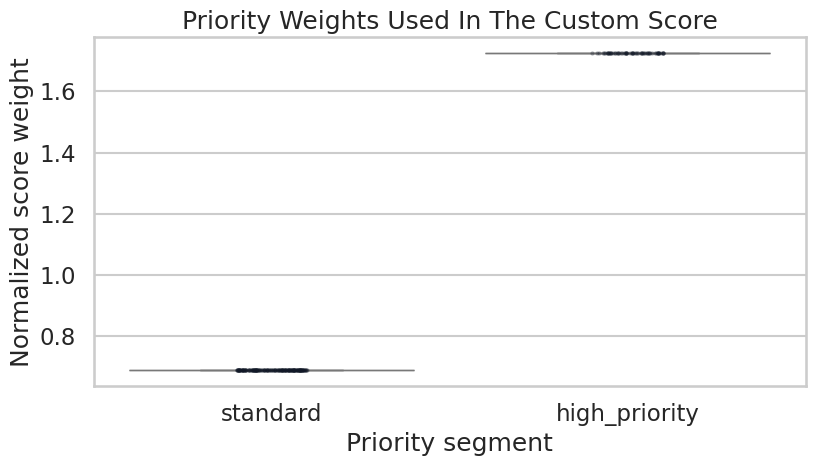

In [13]:
weight_plot_df = plr_df[["priority_segment"]].assign(priority_weight=priority_weights)

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.boxplot(data=weight_plot_df, x="priority_segment", y="priority_weight", color="#93c5fd", ax=ax)
sns.stripplot(data=weight_plot_df.sample(250, random_state=RANDOM_SEED), x="priority_segment", y="priority_weight", color="#111827", alpha=0.35, size=3, ax=ax)
ax.set_title("Priority Weights Used In The Custom Score")
ax.set_xlabel("Priority segment")
ax.set_ylabel("Normalized score weight")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_priority_weights.png", dpi=160, bbox_inches="tight")
plt.show()

The high-priority group receives larger score weight by design. Since the weights are normalized, the average weight is one.

For causal interpretation, this is a support check: weak overlap can make an estimator depend on extrapolation instead of comparable treated and control units.
<!-- result-implication-expanded -->




#### A Deliberately Bad Score as a Caution

The code below fits a non-orthogonal raw score that ignores the treatment nuisance model and does not residualize the treatment. This score is included to show that DoubleML will execute a callable score if it has the right shape. Validity as a causal moment still requires the correct orthogonal score construction.

In [14]:
# Define reusable helpers for the A Deliberately Bad Score As A Caution section.
def nonorthogonal_raw_score(y, d, l_hat, m_hat, g_hat, smpls):
    """
    Idea: Compute the nonorthogonal raw score needed in the A Deliberately Bad Score As A Caution section and return it in a form the next cells can inspect.
    
    Parameters
    ----------
    y : str or array-like
        Outcome, second variable, or numeric input in the comparison.
    d : object
        Treatment or decision indicator used by the causal score.
    l_hat : object
        Estimated outcome nuisance prediction used by the orthogonal score.
    m_hat : object
        Estimated treatment or propensity nuisance prediction used by the orthogonal score.
    g_hat : object
        Estimated outcome regression prediction used by the score.
    smpls : object
        Sample-splitting structure passed into DoubleML.
    
    Returns
    -------
    np.ndarray
        Nonorthogonal raw score contributions used as a contrast with the orthogonal score.
    """
    psi_a = -d * d
    psi_b = d * y
    return psi_a, psi_b

bad_score_plr = fit_plr(
    plr_df,
    x_cols,
    learner_l=base_learner,
    learner_m=base_learner,
    score=nonorthogonal_raw_score,
    sample_splits=sample_splits,
)

bad_score_result = pd.DataFrame([extract_plr_row("Non-orthogonal raw score caution", bad_score_plr)])
save_table(bad_score_result, f"{NOTEBOOK_PREFIX}_bad_score_caution.csv")
display(bad_score_result)


,model,estimate,std_error,ci_95_lower,ci_95_upper,true_theta,absolute_error
0,Non-orthogonal raw score caution,1.3535,0.0316,1.2917,1.4154,1.2500,0.1035


The cautionary score is farther from the known truth. The lesson is sharp: a callable score is an API hook, not a validity certificate.

#### Compare Score Variants

This table combines the built-in score, equivalent callable score, priority-weighted score, and cautionary raw score.

In [15]:
score_comparison = pd.concat(
    [builtin_result, callable_result, weighted_result, bad_score_result],
    ignore_index=True,
)
score_comparison = score_comparison.sort_values("absolute_error")

save_table(score_comparison, f"{NOTEBOOK_PREFIX}_score_variant_comparison.csv")
display(score_comparison)

,model,estimate,std_error,ci_95_lower,ci_95_upper,true_theta,absolute_error
0,Built-in partialling out,1.2852,0.0359,1.2148,1.3556,1.2500,0.0352
1,Callable partialling out,1.2852,0.0359,1.2148,1.3556,1.2500,0.0352
2,Priority-weighted callable score,1.2890,0.0381,1.2144,1.3636,1.2500,0.0390
3,Non-orthogonal raw score caution,1.3535,0.0316,1.2917,1.4154,1.2500,0.1035


The built-in and equivalent callable scores match. The priority-weighted score remains close. The raw non-orthogonal score is a useful warning about custom-score responsibility.

For causal interpretation, this is a support check: weak overlap can make an estimator depend on extrapolation instead of comparable treated and control units.
<!-- result-implication-expanded -->


#### Plot Score Variant Estimates

The estimate plot makes the custom-score comparison easier to scan. The vertical line marks the true effect in the simulation.

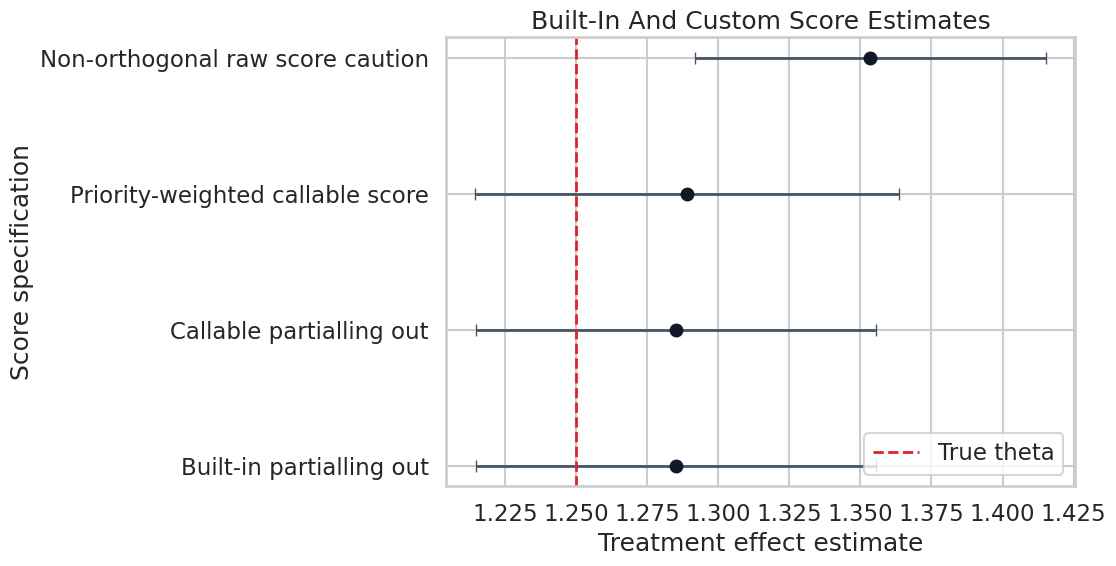

In [16]:
# Build and label the diagnostic visualization for the Plot Score Variant Estimates section.
plot_scores = score_comparison.sort_values("estimate")
y_positions = np.arange(len(plot_scores))

fig, ax = plt.subplots(figsize=(11.5, 6))
ax.errorbar(
    x=plot_scores["estimate"],
    y=y_positions,
    xerr=np.vstack([
        plot_scores["estimate"] - plot_scores["ci_95_lower"],
        plot_scores["ci_95_upper"] - plot_scores["estimate"],
    ]),
    fmt="o",
    color="#111827",
    ecolor="#475569",
    elinewidth=2,
    capsize=4,
)
ax.axvline(TRUE_THETA, color="#dc2626", linestyle="--", linewidth=2, label="True theta")
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_scores["model"])
ax.set_title("Built-In And Custom Score Estimates")
ax.set_xlabel("Treatment effect estimate")
ax.set_ylabel("Score specification")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_score_variant_estimates.png", dpi=160, bbox_inches="tight")
plt.show()


The plot helps separate extension from experimentation. A custom score should be expected to behave in a known way; surprising movement is a reason to inspect the score, not a reason to celebrate.

#### Score Contribution Diagnostics

The next cell extracts score contributions from the built-in and custom models. After plugging in the fitted coefficient, the final score contribution is:

$$
\hat{\psi}_i = \psi_{a,i}\hat{\theta} + \psi_{b,i}.
$$

For a successfully solved linear score, the empirical mean should be near zero:

$$
\frac{1}{n}\sum_{i=1}^{n}\hat{\psi}_i \approx 0.
$$

We compare the score-implied coefficient and the spread of $\hat{\psi}_i$. The mean checks whether the moment equation was solved; the spread and tails help identify unstable score behavior.

In [17]:
# Define reusable helpers for the Score Contribution Diagnostics section.
def score_diagnostic_row(label, model):
    """
    Idea: Compute the diagnostic row values used to diagnose model fit, balance, or policy value.
    
    Parameters
    ----------
    label : str
        Short label attached to a scenario, method, or plotted result.
    model : object
        Fitted model or model specification used by the diagnostic.
    
    Returns
    -------
    dict[str, object]
        Summary row describing score mean, correlation, and sensitivity to nuisance perturbation.
    """
    psi_a = model.psi_elements["psi_a"].reshape(-1)
    psi_b = model.psi_elements["psi_b"].reshape(-1)
    theta = float(model.coef[0])
    final_score = psi_a * theta + psi_b
    return {
        "model": label,
        "theta_from_score_elements": solve_linear_score(psi_a, psi_b),
        "mean_final_score": float(np.mean(final_score)),
        "std_final_score": float(np.std(final_score)),
        "score_p01": float(np.quantile(final_score, 0.01)),
        "score_p99": float(np.quantile(final_score, 0.99)),
    }

score_diagnostics = pd.DataFrame(
    [
        score_diagnostic_row("Built-in partialling out", builtin_plr),
        score_diagnostic_row("Callable partialling out", callable_plr),
        score_diagnostic_row("Priority-weighted callable score", weighted_plr),
        score_diagnostic_row("Non-orthogonal raw score caution", bad_score_plr),
    ]
)

save_table(score_diagnostics, f"{NOTEBOOK_PREFIX}_score_diagnostics.csv")
display(score_diagnostics)


,model,theta_from_score_elements,mean_final_score,std_final_score,score_p01,score_p99
0,Built-in partialling out,1.2852,-0.0000,1.1885,-2.9024,3.0922
1,Callable partialling out,1.2852,-0.0000,1.1885,-2.9024,3.0922
2,Priority-weighted callable score,1.2890,-0.0000,1.2416,-3.8380,3.9954
3,Non-orthogonal raw score caution,1.3535,0.0000,1.5268,-4.4432,4.6343


The mean final score is near zero because the estimate solves the empirical moment equation. The spread and tails help identify unstable score behavior.

#### Plot Score Contributions

The histogram below compares final score contributions after plugging in each model's estimated coefficient.

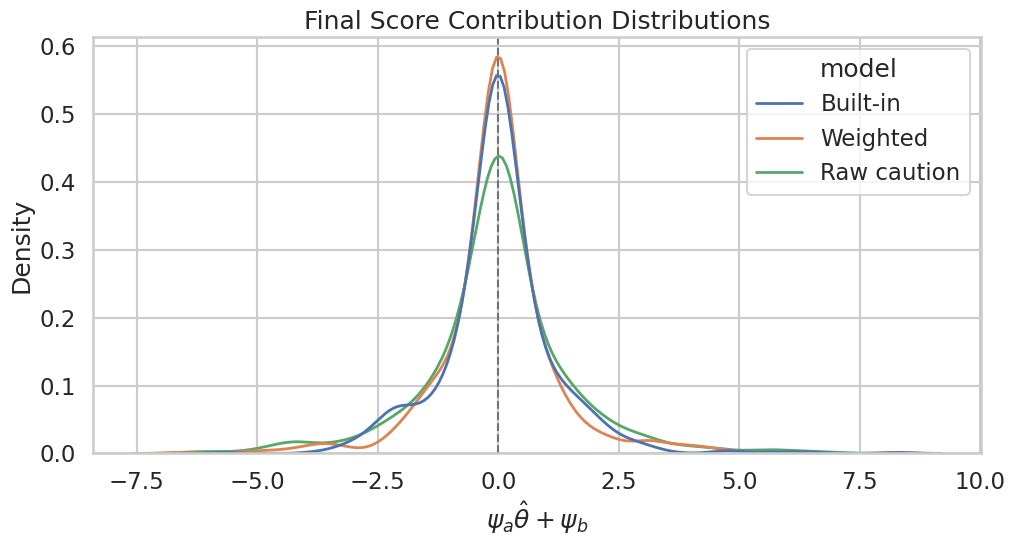

In [18]:
score_distribution_df = pd.concat(
    [
        pd.DataFrame({"model": "Built-in", "final_score": builtin_plr.psi_elements["psi_a"].reshape(-1) * builtin_plr.coef[0] + builtin_plr.psi_elements["psi_b"].reshape(-1)}),
        pd.DataFrame({"model": "Weighted", "final_score": weighted_plr.psi_elements["psi_a"].reshape(-1) * weighted_plr.coef[0] + weighted_plr.psi_elements["psi_b"].reshape(-1)}),
        pd.DataFrame({"model": "Raw caution", "final_score": bad_score_plr.psi_elements["psi_a"].reshape(-1) * bad_score_plr.coef[0] + bad_score_plr.psi_elements["psi_b"].reshape(-1)}),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
sns.kdeplot(
    data=score_distribution_df,
    x="final_score",
    hue="model",
    common_norm=False,
    linewidth=2,
    ax=ax,
)
ax.axvline(0, color="#6b7280", linestyle="--", linewidth=1.5)
ax.set_title("Final Score Contribution Distributions")
ax.set_xlabel(r"$\psi_a \hat{\theta} + \psi_b$")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_score_contribution_distributions.png", dpi=160, bbox_inches="tight")
plt.show()


Score distributions with extreme tails deserve attention. In applied work, this can point to overlap problems, unstable residualized treatment, or a score that is not well matched to the design.



### External Nuisance Predictions

DoubleML can accept nuisance predictions from an external ML pipeline. For PLR, the nested dictionary shape is:

```python
{
 "treatment": {
 "ml_l": array_of_l_hat_with_shape_(n_obs, n_rep),
 "ml_m": array_of_m_hat_with_shape_(n_obs, n_rep),
 }
}
```

Here we create the external predictions manually using the same folds. This mirrors how a production ML team might supply predictions while the causal analysis team uses DoubleML for score estimation and inference.


In [19]:
# Save the artifacts produced by the External Nuisance Predictions section.
external_l_hat, external_m_hat = manual_cross_fit_predictions(
    plr_df,
    x_cols,
    sample_splits,
    learner_l=base_learner,
    learner_m=base_learner,
)

external_predictions = {
    "treatment": {
        "ml_l": external_l_hat.reshape(-1, 1),
        "ml_m": external_m_hat.reshape(-1, 1),
    }
}

external_prediction_model = fit_plr(
    plr_df,
    x_cols,
    learner_l=base_learner,
    learner_m=base_learner,
    score="partialling out",
    sample_splits=sample_splits,
    external_predictions=external_predictions,
)

external_prediction_result = pd.DataFrame([extract_plr_row("External nuisance predictions", external_prediction_model)])
save_table(external_prediction_result, f"{NOTEBOOK_PREFIX}_external_prediction_result.csv")
display(external_prediction_result)


,model,estimate,std_error,ci_95_lower,ci_95_upper,true_theta,absolute_error
0,External nuisance predictions,1.2852,0.0359,1.2148,1.3556,1.2500,0.0352


The external-prediction estimate matches the built-in pipeline because the same folds and same learners generated the predictions. This is the desired smoke test before connecting a more complex external pipeline.



#### Compare Internal and External Predictions

The code below checks that the manually supplied external predictions match the predictions stored by the built-in DoubleML fit.

In [20]:
internal_l_hat = builtin_plr.predictions["ml_l"][:, 0, 0]
internal_m_hat = builtin_plr.predictions["ml_m"][:, 0, 0]

external_prediction_audit = pd.DataFrame(
    [
        {"prediction": "ml_l", "max_abs_difference": float(np.max(np.abs(internal_l_hat - external_l_hat))), "rmse_difference": rmse(internal_l_hat, external_l_hat)},
        {"prediction": "ml_m", "max_abs_difference": float(np.max(np.abs(internal_m_hat - external_m_hat))), "rmse_difference": rmse(internal_m_hat, external_m_hat)},
        {"prediction": "theta", "max_abs_difference": abs(float(builtin_plr.coef[0]) - float(external_prediction_model.coef[0])), "rmse_difference": np.nan},
    ]
)

save_table(external_prediction_audit, f"{NOTEBOOK_PREFIX}_external_prediction_audit.csv")
display(external_prediction_audit)

,prediction,max_abs_difference,rmse_difference
0,ml_l,0.0000,0.0000
1,ml_m,0.0000,0.0000
2,theta,0.0000,NaN


The differences are zero or numerically tiny. This confirms the dictionary shape and row order are correct.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


#### Stored Fold Models and Feature Importance

With `store_models=True`, DoubleML keeps the fold-level nuisance models. The code below extracts average random-forest feature importance across the stored `ml_l` and `ml_m` models.

In [21]:
importance_rows = []
for learner_name in ["ml_l", "ml_m"]:
    fold_models = builtin_plr.models[learner_name]["treatment"][0]
    for fold_number, model in enumerate(fold_models):
        for feature, importance in zip(x_cols, model.feature_importances_):
            importance_rows.append(
                {
                    "learner": learner_name,
                    "fold": fold_number,
                    "feature": feature,
                    "importance": float(importance),
                }
            )

feature_importance = pd.DataFrame(importance_rows)
feature_importance_summary = (
    feature_importance.groupby(["learner", "feature"])
    .agg(mean_importance=("importance", "mean"), std_importance=("importance", "std"))
    .reset_index()
    .sort_values(["learner", "mean_importance"], ascending=[True, False])
)

save_table(feature_importance_summary, f"{NOTEBOOK_PREFIX}_stored_model_feature_importance.csv")
display(feature_importance_summary.head(12))


,learner,feature,mean_importance,std_importance
1,ml_l,x01,0.2959,0.0219
0,ml_l,x00,0.2863,0.0148
2,ml_l,x02,0.1494,0.0221
7,ml_l,x07,0.0674,0.0125
4,ml_l,x04,0.0538,0.0068
6,ml_l,x06,0.0515,0.0073
3,ml_l,x03,0.0485,0.0117
5,ml_l,x05,0.0472,0.0124
9,ml_m,x01,0.3679,0.0235
8,ml_m,x00,0.2717,0.0070


Stored fold models are useful for auditing, but feature importance is still an ML diagnostic. It does not prove causal importance of a covariate.

#### Plot Stored-Model Feature Importance

The plot below compares the nuisance models for outcome and treatment. Different important features are expected because `ml_l` predicts `Y` and `ml_m` predicts `D`.

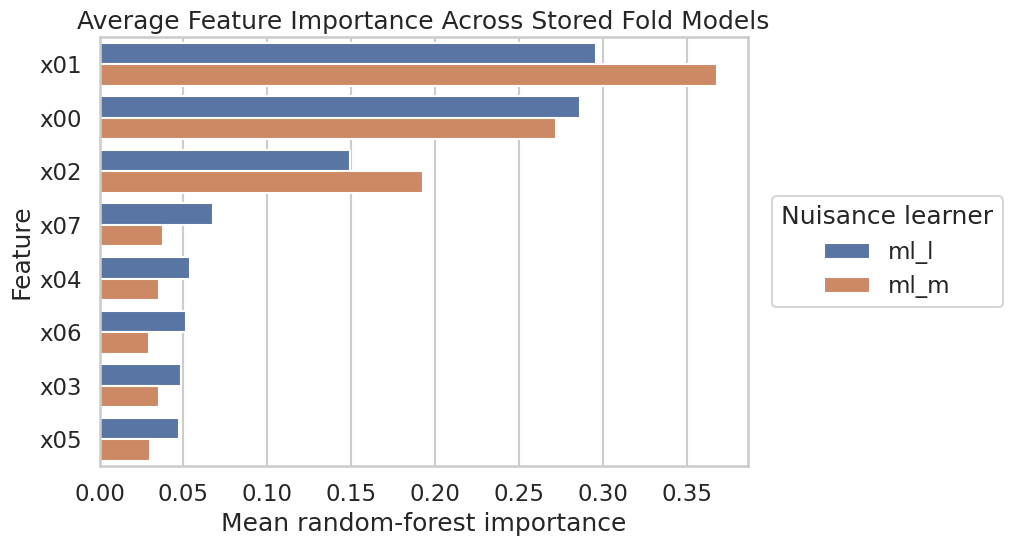

In [22]:
fig, ax = plt.subplots(figsize=(10.5, 5.8))
sns.barplot(
    data=feature_importance_summary,
    x="mean_importance",
    y="feature",
    hue="learner",
    ax=ax,
)
ax.set_title("Average Feature Importance Across Stored Fold Models")
ax.set_xlabel("Mean random-forest importance")
ax.set_ylabel("Feature")
ax.legend(title="Nuisance learner", loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_stored_model_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()


The treatment model emphasizes features involved in `true_m`, while the outcome model emphasizes features involved in both outcome prediction and treatment-related variation. This is a useful sanity check against the simulator.




## Reporting and Takeaways

### Custom Score Validation Checklist

The table below converts the notebook into a checklist. A custom score should not be merged into a serious analysis until it passes checks like these.

| check | guidance |
| --- | --- |
| Known-score recreation | First recreate a built-in score exactly using the callable interface. |
| Shape check | Confirm psi_a and psi_b are finite arrays aligned with the original row order. |
| Moment check | Verify that mean(psi_a * theta_hat + psi_b) is approximately zero. |
| Orthogonality argument | Write the mathematical reason why nuisance errors have only second-order impact. |
| Split reproducibility | Use fixed sample splits when comparing scores or external predictions. |
| External prediction audit | Check row order, shape, and fold origin of external nuisance predictions. |
| Unsupported features | Document DoubleML features unavailable for callable scores, such as sensitivity analysis in this version. |
| Simulation test | Test the score on data where the truth is known before using it on real data. |


The checklist is deliberately stricter than merely running without errors. Custom scores are extension points, so the burden of proof moves to the analyst.

### Advanced API Summary

This table summarizes the advanced APIs used in the notebook and the caution attached to each.

| api | used_for | main_caution |
| --- | --- | --- |
| score=callable | Custom score elements | DoubleML checks shape and execution, not causal validity. |
| set_sample_splitting() | Reproducible fold assignment | The split must match the data design; random folds are not always appropriate. |
| external_predictions | Supplying nuisance predictions | Predictions must be cross-fitted, row-aligned, and shaped as (n_obs, n_rep). |
| store_models=True | Auditing fitted nuisance models | Model diagnostics are not causal evidence. |
| psi_elements | Score reconstruction and diagnostics | Score diagnostics can reveal instability but do not replace identification assumptions. |
| evaluate_learners() | Out-of-fold nuisance loss | Low predictive loss is helpful but not sufficient for causal credibility. |


The advanced API is powerful because it lets DoubleML interoperate with custom ML and custom moments. That same flexibility is why documentation and testing are part of the analysis, not an afterthought.

### Write a Reusable Report Template

This report template captures how a custom-score analysis should be documented.

In [23]:
report_template = rf"""# Custom Score And Advanced DoubleML API Report Template

## Causal Estimand
State the target parameter and the model assumptions. Explain why a built-in DoubleML score is or is not sufficient.

## Score Definition
Write the score as $\psi(W; \theta, \eta) = \psi_a(W; \eta)\theta + \psi_b(W; \eta)$. Include the callable function signature and all nuisance inputs.

## Orthogonality Argument
Explain why the score is Neyman-orthogonal. If the score is not orthogonal, do not present it as a DoubleML-style robust estimator.

## Reproducibility Checks
Document sample splitting, random seeds, learner settings, and whether external nuisance predictions were supplied.

## Validation Results
Report known-score recreation, score reconstruction, final score mean, nuisance diagnostics, and any simulation checks with known truth.

## Unsupported Or Limited Features
Document any DoubleML features that are unavailable for callable scores in the installed version.

## Decision Boundary
State what the custom score supports and what still needs theory, robustness checks, or experimental validation.

Key estimate from this lesson:
- Built-in PLR estimate: {float(builtin_plr.coef[0]):.4f}
- Callable equivalent estimate: {float(callable_plr.coef[0]):.4f}
- Priority-weighted callable estimate: {float(weighted_plr.coef[0]):.4f}
- True $\theta_0$ in simulation: {TRUE_THETA:.4f}
"""

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_custom_score_report_template.md"
report_path.write_text(report_template)

print(f"Wrote report template to: {report_path}")


Wrote report template to: /home/apex/Documents/portfolio/notebooks/tutorials/doubleml/outputs/reports/16_custom_score_report_template.md


The template forces the custom score to be documented mathematically and operationally. That is exactly the habit this lesson is trying to build.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


The outputs make the notebook reviewable as a small extension package: data, score comparisons, diagnostics, figures, and a report template are all saved.


### What Comes Next

The next tutorial covers common pitfalls, diagnostics, and reporting. That is the natural follow-up because custom scores make good reporting even more important.

The main lesson from this lesson is that DoubleML's advanced API gives you access to the estimating equation. That is powerful, but it shifts responsibility toward the analyst. A valid custom score needs a clear estimand, an orthogonality argument, reproducible nuisance predictions, and simulation tests before it belongs in a real causal analysis.